In [2]:
import torch
import torchvision
import torchvision.transforms as transforms

In [3]:
transform = transforms.Compose(
    [transforms.ToTensor(),
     transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
     ])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=4, shuffle=True, num_workers=2)
testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=4, shuffle=False, num_workers=2)

classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

torch.Size([4, 3, 32, 32])
torch.Size([3, 36, 138])


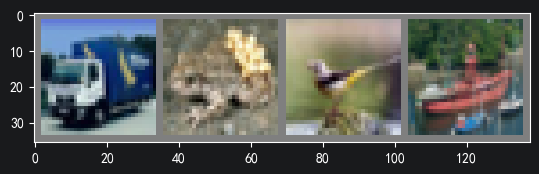

truck  frog  bird  ship


In [7]:
import matplotlib.pyplot as plt
import numpy as np
# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei']  # 使用黑体
plt.rcParams['axes.unicode_minus'] = False    # 解决负号显示问题

def imgshow(img):
    print(img.size())
    img = img / 2 + 0.5
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

dataiter = iter(trainloader)
images, labels = next(dataiter)

print(images.size())
imgshow(torchvision.utils.make_grid(images))
print(' '.join("%5s" % classes[labels[j]] for j in range(4)))

In [13]:
import torch.nn as nn
import torch.nn.functional as F

class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.conv1 = nn.Conv2d(3, 6, 5)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 16 * 5 * 5)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

net = Net()

In [23]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=0.004, momentum=0.9)

In [25]:
for epoch in range(10):
    running_loss = 0.0
    for i, data in enumerate(trainloader, 0):
        inputs, labels = data
        optimizer.zero_grad()

        outputs = net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        if i % 2000 == 1999:
            print(f'[%d, %5d] loss: %.3f' % (epoch + 1, i + 1, running_loss / 2000))
            running_loss = 0.0
print('Finished Training')

[1,  2000] loss: 1.755
[1,  4000] loss: 1.728
[1,  6000] loss: 1.759
[1,  8000] loss: 1.731
[1, 10000] loss: 1.715
[1, 12000] loss: 1.731
[2,  2000] loss: 1.712
[2,  4000] loss: 1.698
[2,  6000] loss: 1.726
[2,  8000] loss: 1.715
[2, 10000] loss: 1.719
[2, 12000] loss: 1.703
[3,  2000] loss: 1.686
[3,  4000] loss: 1.687
[3,  6000] loss: 1.678
[3,  8000] loss: 1.692
[3, 10000] loss: 1.681
[3, 12000] loss: 1.674
[4,  2000] loss: 1.658
[4,  4000] loss: 1.648
[4,  6000] loss: 1.666
[4,  8000] loss: 1.692
[4, 10000] loss: 1.667
[4, 12000] loss: 1.697
[5,  2000] loss: 1.647
[5,  4000] loss: 1.666
[5,  6000] loss: 1.653
[5,  8000] loss: 1.669
[5, 10000] loss: 1.662
[5, 12000] loss: 1.648
[6,  2000] loss: 1.627
[6,  4000] loss: 1.627
[6,  6000] loss: 1.643
[6,  8000] loss: 1.638
[6, 10000] loss: 1.648
[6, 12000] loss: 1.657
[7,  2000] loss: 1.616
[7,  4000] loss: 1.617
[7,  6000] loss: 1.616
[7,  8000] loss: 1.628
[7, 10000] loss: 1.623
[7, 12000] loss: 1.642
[8,  2000] loss: 1.632
[8,  4000] 

In [27]:
correct = 0
total = 0
with torch.no_grad():
    for data in testloader:
        images, labels = data
        outputs = net(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
print('Accuracy of the network on the 10000 test images: %d %%' % (100 * correct / total))

Accuracy of the network on the 10000 test images: 39 %


In [28]:
class_correct = list(0. for i in range(10))
class_total = list(0. for i in range(10))
with torch.no_grad():
    for data in testloader:
        images, labels = data
        outputs = net(images)
        _, predicted = torch.max(outputs, 1)
        c = (predicted == labels).squeeze()
        for i in range(4):
            label = labels[i]
            class_correct[label] += c[i].item()
            class_total[label] += 1

for i in range(10):
    print('Accuracy of %5s : %2d %%' % (classes[i], 100 * class_correct[i] / class_total[i]))

Accuracy of plane : 49 %
Accuracy of   car : 37 %
Accuracy of  bird : 12 %
Accuracy of   cat :  5 %
Accuracy of  deer : 26 %
Accuracy of   dog : 42 %
Accuracy of  frog : 76 %
Accuracy of horse : 46 %
Accuracy of  ship : 34 %
Accuracy of truck : 62 %
